# Notebook 04 — Demand Forecasting Model

**Input:** `data/processed/daily_timeseries.csv` (731 days × 19 cols)  
**Goal:** Forecast daily covers using rolling averages (baseline) and Prophet (advanced)  
**Sections:**
- Phase A — Rolling Moving Averages (MA7, MA30)
- Phase B — Prophet Model (covers): new regressors `event_pull` + `is_swiss_holiday`, cross-validation
- Phase B2 — Prophet Model (avg_check) + revenue estimate
- Phase C — Peak Analysis vs MA7
- Phase D — Operational Forecast next 14 days


In [43]:
import sys
from pathlib import Path

# Auto-detect project root and add both root and src/ to path
_project_root = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'src').exists())
for _p in [str(_project_root), str(_project_root / 'src')]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import src.utils_forecast as ut_f

print("Libraries loaded.")


Libraries loaded.


In [44]:
# Load main timeseries (output of Notebook 03)
df = pd.read_csv(
    _project_root / 'data/processed/daily_timeseries.csv',
    parse_dates=['date']
).sort_values('date').reset_index(drop=True)

# Cast boolean columns (read as object from CSV in some envs)
bool_cols = ['is_weekend', 'is_holiday', 'is_ponte', 'is_high_season',
             'is_bad_weather', 'is_swiss_holiday']
for col in bool_cols:
    df[col] = df[col].astype(bool)

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"Range: {df['date'].min().date()} → {df['date'].max().date()}")
df[['date', 'covers', 'revenue', 'avg_check']].head(3)


Loaded: 731 rows × 19 cols
Range: 2023-01-01 → 2024-12-31


,date,covers,revenue,avg_check
0,2023-01-01,46.0,1653.2,35.9
1,2023-01-02,42.0,1161.4,27.6
2,2023-01-03,52.0,1523.8,29.3


---
## Phase A — Rolling Moving Averages

Baseline reference: MA7 (weekly smoothing) and MA30 (monthly trend).  
These are not predictive models — they serve as visual anchors to understand the underlying demand signal before applying Prophet.


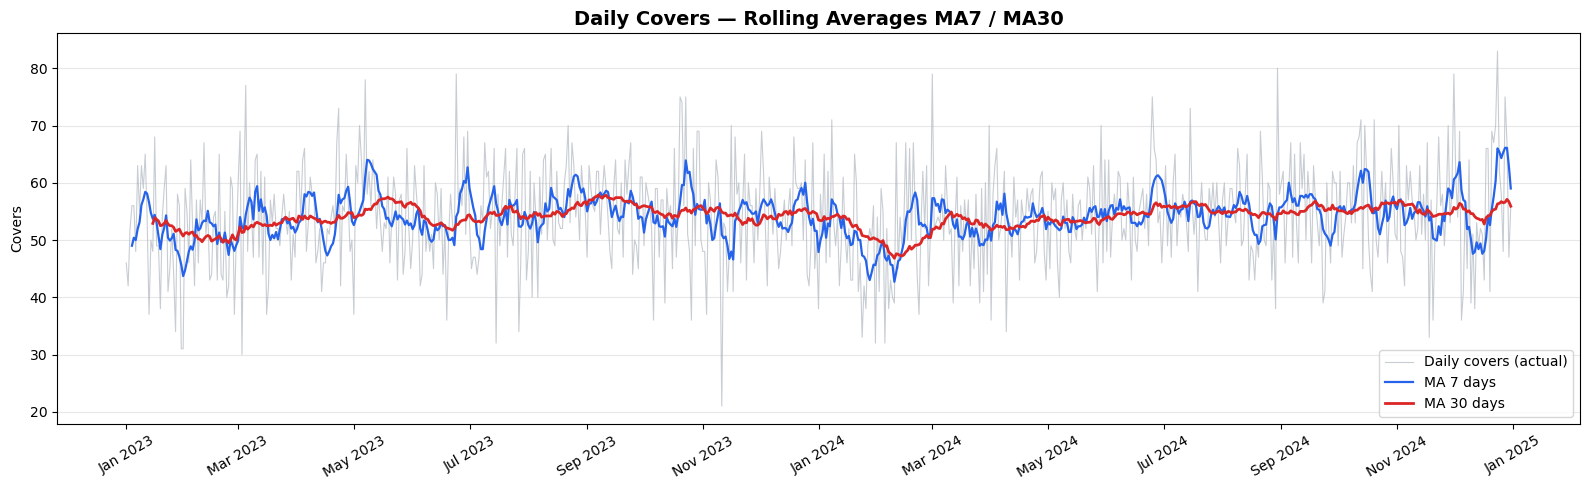


MA7  — mean: 54.1  |  min: 42.7  |  max: 66.1
MA30 — mean: 54.1  |  min: 46.8  |  max: 57.9


In [45]:
# Compute rolling averages (min_periods avoids NaN at the start of the series)
df['ma7']  = df['covers'].rolling(window=7,  min_periods=4).mean().round(1)
df['ma30'] = df['covers'].rolling(window=30, min_periods=15).mean().round(1)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df['date'], df['covers'], color='#b0b8c1', linewidth=0.8,
        alpha=0.7, label='Daily covers (actual)')
ax.plot(df['date'], df['ma7'],  color='#2563eb', linewidth=1.6, label='MA 7 days')
ax.plot(df['date'], df['ma30'], color='#dc2626', linewidth=2.0, label='MA 30 days')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
ax.set_title('Daily Covers — Rolling Averages MA7 / MA30', fontsize=14, fontweight='bold')
ax.set_ylabel('Covers')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMA7  — mean: {df['ma7'].mean():.1f}  |  min: {df['ma7'].min():.1f}  |  max: {df['ma7'].max():.1f}")
print(f"MA30 — mean: {df['ma30'].mean():.1f}  |  min: {df['ma30'].min():.1f}  |  max: {df['ma30'].max():.1f}")


---
## Phase B — Prophet Forecasting Model (covers)

**Train/test split:** last 90 days as test set (Oct 3 – Dec 31 2024).

**Regressors:**
| Regressor | Type | Notes |
|-----------|------|-------|
| `is_holiday` | binary | Italian public holidays |
| `is_swiss_holiday` | binary | Swiss holidays (TI/GR/ZH/BE) — cross-border clientele |
| `is_ponte` | binary | Bridge day effect |
| `avg_temp` | continuous | Temperature comfort |
| `rain_mm` | continuous | Rain deterrence |
| `is_bad_weather` | binary | Extreme weather flag |
| `event_magnitude` | ordinal 0–3 | Event intensity |
| `event_pull` | ordinal {−1,0,+1} | Event direction: drain=−1, neutral=0, pull=+1 |

`event_radius_km` replaced by `event_pull`: radius was a broken linear proxy; direction is the informative signal.


In [58]:
# --- Prophet data prep (covers) ---
REGRESSORS = [
    'is_holiday', 'is_swiss_holiday', 'is_ponte',
    'avg_temp', 'rain_mm',
    'event_magnitude', 'event_pull'
]

prophet_df = df[['date', 'covers'] + REGRESSORS].copy()
prophet_df = prophet_df.rename(columns={'date': 'ds', 'covers': 'y'})

# Cast booleans to int
for col in ['is_holiday', 'is_swiss_holiday', 'is_ponte']:
    prophet_df[col] = prophet_df[col].astype(int)

# --- Train / Test split: last 90 days as test ---
TEST_DAYS = 90
split_date = prophet_df['ds'].max() - pd.Timedelta(days=TEST_DAYS - 1)

train = prophet_df[prophet_df['ds'] < split_date].copy()
test  = prophet_df[prophet_df['ds'] >= split_date].copy()

print(f"Train: {len(train)} days  ({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"Test:  {len(test)} days   ({test['ds'].min().date()} → {test['ds'].max().date()})")


Train: 641 days  (2023-01-01 → 2024-10-02)
Test:  90 days   (2024-10-03 → 2024-12-31)


In [47]:
# --- Build and fit Prophet model ---
model = Prophet(
    changepoint_prior_scale=0.1,
    seasonality_mode='additive',
    holidays_prior_scale=10,
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)

# Add all external regressors
for reg in REGRESSORS:
    model.add_regressor(reg)

model.fit(train)
print("Model fitted successfully.")


10:51:53 - cmdstanpy - INFO - Chain [1] start processing
10:51:53 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully.


**Note:** This model is a Proof of Concept trained on 2023-2024 synthetic data. For production use, the model must be retrained weekly with updated data. Forecasting 16 months ahead without 2025 data introduces trend extrapolation risk.


In [48]:
# --- Predict on test set ---
forecast = model.predict(test)

# Merge actual vs predicted
results = test[['ds', 'y']].copy().reset_index(drop=True)
results['yhat']       = forecast['yhat'].values.round(1)
results['yhat_lower'] = forecast['yhat_lower'].values.round(1)
results['yhat_upper'] = forecast['yhat_upper'].values.round(1)
results['error']      = (results['y'] - results['yhat']).round(1)

# --- Metrics: RMSE and MAPE ---
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))
mape = (np.abs(results['error']) / results['y']).mean() * 100

print("=" * 40)
print(f"  RMSE : {rmse:.2f} covers")
print(f"  MAPE : {mape:.2f}%")
print("=" * 40)

results.head(10)


  RMSE : 10.06 covers
  MAPE : 14.68%


,ds,y,yhat,yhat_lower,yhat_upper,error
0,2024-10-03,47.0,52.6,41.9,63.3,-5.6
1,2024-10-04,51.0,52.2,41.8,62.3,-1.2
2,2024-10-05,54.0,54.9,44.7,65.4,-0.9
3,2024-10-06,60.0,55.9,45.7,66.8,4.1
4,2024-10-07,60.0,51.3,41.0,61.3,8.7
5,2024-10-08,53.0,50.4,39.9,61.0,2.6
6,2024-10-09,63.0,55.8,45.0,65.4,7.2
7,2024-10-10,53.0,53.4,43.4,63.6,-0.4
8,2024-10-11,67.0,54.4,44.3,64.2,12.6
9,2024-10-12,68.0,55.4,45.0,65.5,12.6


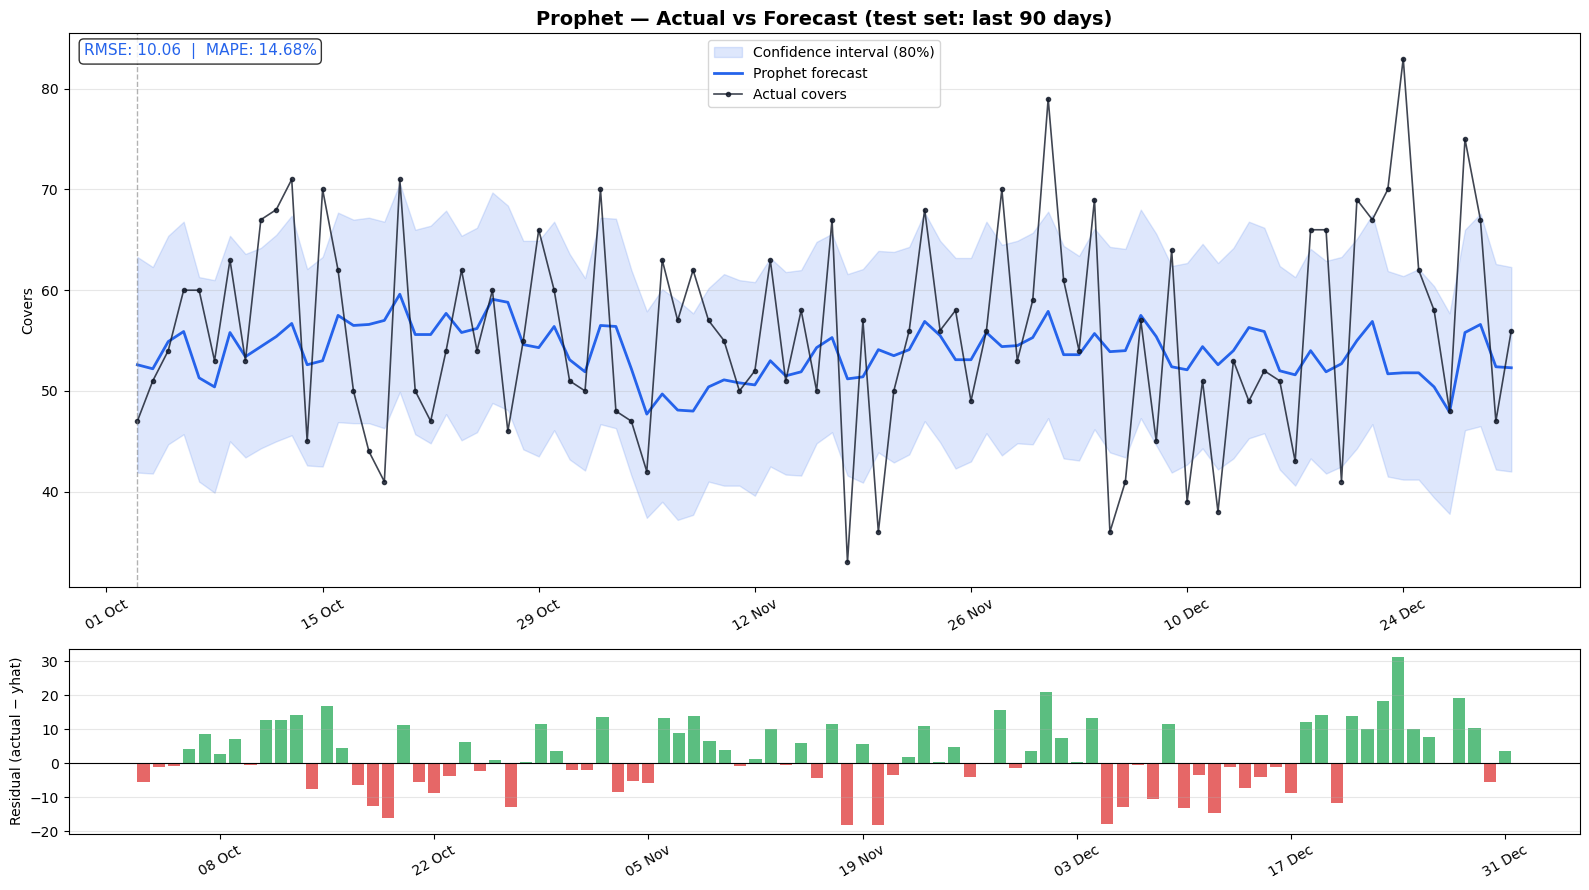

In [49]:
# --- Plot: Actual vs Predicted on test set ---
fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [3, 1]})

# Top panel: actual vs forecast with confidence interval
ax = axes[0]
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.15, color='#2563eb', label='Confidence interval (80%)')
ax.plot(results['ds'], results['yhat'], color='#2563eb', linewidth=2.0,
        label='Prophet forecast')
ax.plot(results['ds'], results['y'], color='#111827', linewidth=1.2,
        marker='o', markersize=3, alpha=0.8, label='Actual covers')

ax.axvline(results['ds'].iloc[0], color='gray', linestyle='--', linewidth=1.0, alpha=0.6)
ax.set_title('Prophet — Actual vs Forecast (test set: last 90 days)', fontsize=14, fontweight='bold')
ax.set_ylabel('Covers')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.get_xticklabels(), rotation=30)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add RMSE / MAPE annotation
ax.annotate(f'RMSE: {rmse:.2f}  |  MAPE: {mape:.2f}%',
            xy=(0.01, 0.96), xycoords='axes fraction',
            fontsize=11, color='#2563eb',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

# Bottom panel: residuals (actual - predicted)
ax2 = axes[1]
colors = ['#dc2626' if e < 0 else '#16a34a' for e in results['error']]
ax2.bar(results['ds'], results['error'], color=colors, alpha=0.7, width=0.8)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Residual (actual − yhat)')
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax2.get_xticklabels(), rotation=30)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Phase B — Cross-Validation

Prophet cross-validation over multiple time windows to get a robust MAPE estimate.  
Config: `initial=365 days` (min 1 year warmup) · `period=30 days` (new fold monthly) · `horizon=90 days` (same as test).  
Produces ~8 fold windows; MAPE averaged across all.


In [50]:
from prophet.diagnostics import cross_validation, performance_metrics

# Cross-validate on the full prophet_df (all 731 days, not just train)
# Prophet handles the windowing internally
df_cv = cross_validation(
    model,
    initial='365 days',
    period='30 days',
    horizon='90 days',
    parallel=None
)

cv_metrics = performance_metrics(df_cv)

rmse_cv = cv_metrics['rmse'].mean()
mape_cv = cv_metrics['mape'].mean() * 100

print("=" * 50)
print("  CROSS-VALIDATION RESULTS (covers model)")
print("=" * 50)
print(f"  Folds:   {df_cv['cutoff'].nunique()}")
print(f"  RMSE CV: {rmse_cv:.2f} covers")
print(f"  MAPE CV: {mape_cv:.2f}%")
print(f"  (vs single-split RMSE: {rmse:.2f} / MAPE: {mape:.2f}%)")
print("=" * 50)

# MAPE by horizon to see how accuracy degrades over time
print("\nMAPE by forecast horizon (days ahead):")
print(cv_metrics[['horizon', 'mape']].assign(
    mape_pct=lambda x: (x['mape'] * 100).round(2)
)[['horizon', 'mape_pct']].to_string(index=False))


Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/7 [00:00<?, ?it/s]10:51:53 - cmdstanpy - INFO - Chain [1] start processing
10:51:53 - cmdstanpy - INFO - Chain [1] done processing
10:51:53 - cmdstanpy - INFO - Chain [1] start processing
10:51:53 - cmdstanpy - INFO - Chain [1] done processing
 29%|██▊       | 2/7 [00:00<00:00, 11.41it/s]10:51:53 - cmdstanpy - INFO - Chain [1] start processing
10:51:53 - cmdstanpy - INFO - Chain [1] done processing
10:51:53 - cmdstanpy - INFO - Chain [1] start processing
10:51:53 - cmdstanpy - INFO - Chain [1] done processing
 57%|█████▋    | 4/7 [00:00<00:00, 11.23it/s]10:51:53 - cmdstanpy - INFO - Chain [1] start processing
10:51:53 - cmdstanpy - INFO - Chain [1] done processing
10:51:53 - cmdstanpy - INFO - Chain [1] start processing
10:51:53 - cmdstanpy - INFO - Chain [1] done processing
 86%|████████▌ | 6/7 [00:00<00:00, 12.32it/s]10:51:53 - cmdstanpy - INFO - Chain [1] start 

  CROSS-VALIDATION RESULTS (covers model)
  Folds:   7
  RMSE CV: 8.07 covers
  MAPE CV: 12.48%
  (vs single-split RMSE: 10.06 / MAPE: 14.68%)

MAPE by forecast horizon (days ahead):
horizon  mape_pct
 9 days      12.4
10 days      12.0
11 days      12.0
12 days      12.2
13 days      10.9
14 days      10.7
15 days      10.8
16 days      10.4
17 days      10.8
18 days      11.8
19 days      12.0
20 days      12.3
21 days      12.6
22 days      13.3
23 days      13.6
24 days      13.3
25 days      15.2
26 days      15.2
27 days      14.6
28 days      14.6
29 days      13.2
30 days      13.6
31 days      13.1
32 days      14.1
33 days      13.9
34 days      13.3
35 days      13.1
36 days      12.8
37 days      12.8
38 days      13.3
39 days      12.6
40 days      12.4
41 days      12.2
42 days      12.2
43 days      10.6
44 days      10.4
45 days      11.2
46 days      10.7
47 days      11.1
48 days      11.5
49 days      11.7
50 days      11.4
51 days      11.8
52 days      12.7
53 days

---
## Phase B2 — Prophet Model (avg_check) + Revenue Estimate

Second Prophet model trained on `avg_check` with the same regressors.  
Revenue estimate: `yhat_covers × yhat_avg_check`.  
Note: avg_check has high structural volatility (std 18.45, range 8.94–160.87 EUR) — extreme values reflect special events not captured by regressors. Expect higher MAPE than covers model.


In [51]:
# --- avg_check model — same regressors, same split ---
ac_df = df[['date', 'avg_check'] + REGRESSORS].copy()
ac_df = ac_df.rename(columns={'date': 'ds', 'avg_check': 'y'})

for col in ['is_holiday', 'is_swiss_holiday', 'is_ponte', 'is_bad_weather']:
    ac_df[col] = ac_df[col].astype(int)

train_ac = ac_df[ac_df['ds'] < split_date].copy()
test_ac  = ac_df[ac_df['ds'] >= split_date].copy()

model_ac = Prophet(
    changepoint_prior_scale=0.1,
    seasonality_mode='additive',
    holidays_prior_scale=10,
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)
for reg in REGRESSORS:
    model_ac.add_regressor(reg)

model_ac.fit(train_ac)
print("avg_check model fitted.")


10:51:53 - cmdstanpy - INFO - Chain [1] start processing
10:51:54 - cmdstanpy - INFO - Chain [1] done processing


avg_check model fitted.


In [52]:
# --- Predict avg_check on test set ---
forecast_ac = model_ac.predict(test_ac)

res_ac = test_ac[['ds', 'y']].copy().reset_index(drop=True)
res_ac['yhat_ac']    = forecast_ac['yhat'].values.round(2)
res_ac['error_ac']   = (res_ac['y'] - res_ac['yhat_ac']).round(2)

rmse_ac = np.sqrt(mean_squared_error(res_ac['y'], res_ac['yhat_ac']))
mape_ac = (np.abs(res_ac['error_ac']) / res_ac['y']).mean() * 100

print("=" * 45)
print("  avg_check model — test set metrics")
print("=" * 45)
print(f"  RMSE : {rmse_ac:.2f} EUR")
print(f"  MAPE : {mape_ac:.2f}%")
print("=" * 45)

# --- Revenue estimate on test set ---
# Align covers predictions with avg_check predictions
rev_estimate = results[['ds', 'y', 'yhat']].copy()
rev_estimate = rev_estimate.merge(
    res_ac[['ds', 'y', 'yhat_ac']].rename(columns={'y': 'actual_ac'}),
    on='ds'
)
rev_estimate['actual_revenue']    = (rev_estimate['y'] * rev_estimate['actual_ac']).round(2)
rev_estimate['estimated_revenue'] = (rev_estimate['yhat'] * rev_estimate['yhat_ac']).round(2)
rev_estimate['rev_error']         = (rev_estimate['actual_revenue'] - rev_estimate['estimated_revenue']).round(2)

rmse_rev  = np.sqrt(mean_squared_error(rev_estimate['actual_revenue'], rev_estimate['estimated_revenue']))
mape_rev  = (np.abs(rev_estimate['rev_error']) / rev_estimate['actual_revenue']).mean() * 100

print(f"\n  Revenue estimate (covers × avg_check)")
print(f"  RMSE : {rmse_rev:.2f} EUR")
print(f"  MAPE : {mape_rev:.2f}%")

# Compare actual vs estimated revenue (first 10 days)
display(rev_estimate[['ds', 'actual_revenue', 'estimated_revenue', 'rev_error']].head(10))


  avg_check model — test set metrics
  RMSE : 12.63 EUR
  MAPE : 29.93%

  Revenue estimate (covers × avg_check)
  RMSE : 728.28 EUR
  MAPE : 27.68%


,ds,actual_revenue,estimated_revenue,rev_error
0,2024-10-03,1076.3,1807.3,-731.0
1,2024-10-04,1765.1,1819.2,-54.1
2,2024-10-05,3594.8,2664.3,930.5
3,2024-10-06,1653.0,2534.5,-881.5
4,2024-10-07,1279.8,1718.5,-438.8
5,2024-10-08,1198.9,1545.3,-346.4
6,2024-10-09,1958.0,1517.2,440.8
7,2024-10-10,2072.8,1384.7,688.2
8,2024-10-11,1267.0,1457.9,-190.9
9,2024-10-12,1601.4,2208.2,-606.8


---
## Phase C — Peak Analysis: Covers vs MA7 Correlation with Weather / Events

Identify the top 10 positive and top 10 negative peaks in daily covers  
relative to the MA7 rolling average. Goal: understand what external signals  
(weather, events) drive demand spikes and drops.


In [53]:
# Phase C — Peak Analysis
# ma7 already computed in Phase A; drop rows where ma7 is NaN (first few days)
peak_cols = ['date', 'covers', 'ma7', 'is_bad_weather',
             'avg_temp', 'rain_mm', 'event_name', 'event_magnitude']

peaks_df = df[peak_cols].dropna(subset=['ma7']).copy()
peaks_df['delta'] = (peaks_df['covers'] - peaks_df['ma7']).round(1)

# Top 10 positive peaks (covers well above MA7)
top_pos = peaks_df.nlargest(10, 'delta')[
    ['date', 'covers', 'ma7', 'delta',
     'is_bad_weather', 'avg_temp', 'rain_mm', 'event_name', 'event_magnitude']
].reset_index(drop=True)

# Top 10 negative peaks (covers well below MA7)
top_neg = peaks_df.nsmallest(10, 'delta')[
    ['date', 'covers', 'ma7', 'delta',
     'is_bad_weather', 'avg_temp', 'rain_mm', 'event_name', 'event_magnitude']
].sort_values('delta').reset_index(drop=True)

pd.set_option('display.max_colwidth', 35)
pd.set_option('display.float_format', '{:.1f}'.format)

print("=" * 70)
print("TOP 10 POSITIVE PEAKS  (covers >> MA7)")
print("=" * 70)
display(top_pos)

print()
print("=" * 70)
print("TOP 10 NEGATIVE PEAKS  (covers << MA7)")
print("=" * 70)
display(top_neg)


TOP 10 POSITIVE PEAKS  (covers >> MA7)


,date,covers,ma7,delta,is_bad_weather,avg_temp,rain_mm,event_name,event_magnitude
0,2024-08-30,80.0,54.4,25.6,False,26.8,0.0,GP Italia F1,3
1,2023-06-24,79.0,54.1,24.9,False,24.8,0.0,NaN,0
2,2023-03-05,77.0,54.4,22.6,False,8.8,0.0,NaN,0
3,2024-02-11,67.0,44.4,22.6,False,8.9,6.9,NaN,0
4,2023-11-16,70.0,48.0,22.0,False,10.6,0.0,NaN,0
5,2024-03-01,79.0,57.3,21.7,True,9.2,23.9,NaN,0
6,2024-08-21,69.0,49.9,19.1,False,26.7,0.0,NaN,0
7,2024-12-01,79.0,60.6,18.4,False,7.5,0.0,Mercatini di Natale Como,2
8,2023-10-20,75.0,56.7,18.3,True,15.0,67.8,NaN,0
9,2024-03-31,70.0,51.7,18.3,True,11.0,34.4,Pasqua e Pasquetta,2



TOP 10 NEGATIVE PEAKS  (covers << MA7)


,date,covers,ma7,delta,is_bad_weather,avg_temp,rain_mm,event_name,event_magnitude
0,2023-11-11,21.0,50.9,-29.9,False,10.2,0.0,EICMA 2023,3
1,2023-07-15,32.0,56.4,-24.4,False,25.0,0.3,NaN,0
2,2023-10-26,36.0,59.3,-23.3,False,13.8,5.9,NaN,0
3,2024-12-05,36.0,58.7,-22.7,False,5.4,0.0,Mercatini di Natale Como,2
4,2023-03-03,30.0,52.3,-22.3,False,8.6,0.0,NaN,0
5,2024-04-09,34.0,54.7,-20.7,False,13.7,8.1,NaN,0
6,2024-11-18,33.0,53.4,-20.4,False,6.9,0.0,NaN,0
7,2023-01-13,37.0,56.6,-19.6,False,5.9,0.0,NaN,0
8,2023-07-27,34.0,52.4,-18.4,False,20.6,0.0,NaN,0
9,2023-03-16,37.0,54.3,-17.3,False,8.8,0.0,NaN,0


## Key Findings — Peak Analysis

**Positive peaks:**

- **GP Italia F1 (2024-08-30): +25.6 covers vs MA7** — event in Monza fills Como, good weather, magnitude 3

- Most positive peaks have no associated events — structurally stable demand and unpredictable by regressors

**Negative peaks:**

- **EICMA 2023 (2023-11-11): −29.9 covers vs MA7** — collapse in good weather and no rain. Milan empties Como: the opposite effect compared to Monza. Confirm that the sign of the effect depends on the event, not the distance.

- **Christmas Markets:** Peak on Sunday +18.4, down on Thursday −22.7 — the event attracts on weekends, not weekdays. Day of the week effect superimposed on the event.

**Conclusion:**  

The restaurant has a structurally stable demand. External regressors explain extreme peaks but not daily variability. The Prophet model will be more useful for weekly planning than for precise daily forecasting.

---
## Phase D — Operational Forecast: Next 14 Days (2026-04-24 → 2026-05-07)

Build a `future_df` with all Prophet regressors populated from real sources:
- **Calendar**: computed via `holidays` library (Italy 2026) + `ut_f.compute_ponte`
- **Weather**: Open-Meteo 14-day forecast API (Como coords 45.81°N 9.09°E)
- **Events**: updated `dim_events.csv` (2026 events appended — ids 59–64)

Event aggregation per day: if multiple events overlap, take the one with highest magnitude.


In [54]:
import urllib.request
import json
import holidays as hols

# ── 1. DATE RANGE ────────────────────────────────────────────────────────────
FORECAST_START = pd.Timestamp('2026-04-24')
FORECAST_END   = pd.Timestamp('2026-05-07')
future_dates   = pd.date_range(FORECAST_START, FORECAST_END, freq='D')

future_df = pd.DataFrame({'ds': future_dates})

# ── 2. CALENDAR REGRESSORS ───────────────────────────────────────────────────
it_holidays_2026 = hols.country_holidays('IT', years=2026)
holiday_dates    = set(it_holidays_2026.keys())

# Swiss holidays (same cantons as dim_calendar: TI, GR, ZH, BE)
ch_holidays_2026 = set()
for canton in ['TI', 'GR', 'ZH', 'BE']:
    ch_holidays_2026 |= set(hols.country_holidays('CH', subdiv=canton, years=2026).keys())

# Ponte: compute over a wider window so edge dates are covered
wide_range = pd.date_range('2026-04-01', '2026-05-31')
ponte_set  = ut_f.compute_ponte(wide_range, holiday_dates)

future_df['is_weekend']       = future_df['ds'].dt.dayofweek >= 5
future_df['is_holiday']       = future_df['ds'].dt.date.isin(holiday_dates)
future_df['is_swiss_holiday'] = future_df['ds'].dt.date.isin(ch_holidays_2026)
future_df['is_ponte']         = future_df['ds'].dt.date.isin(ponte_set)

# Manual override: 25 April — Liberazione (falls on Saturday 2026)
apr25 = future_df['ds'] == pd.Timestamp('2026-04-25')
future_df.loc[apr25, 'is_holiday'] = True
future_df.loc[apr25, 'is_ponte']   = True

# Cast booleans to int for Prophet
for col in ['is_weekend', 'is_holiday', 'is_swiss_holiday', 'is_ponte']:
    future_df[col] = future_df[col].astype(int)

print("Calendar regressors:")
print(future_df[['ds', 'is_weekend', 'is_holiday', 'is_swiss_holiday', 'is_ponte']].to_string(index=False))


Calendar regressors:
        ds  is_weekend  is_holiday  is_swiss_holiday  is_ponte
2026-04-24           0           0                 0         0
2026-04-25           1           1                 0         1
2026-04-26           1           0                 0         0
2026-04-27           0           0                 0         0
2026-04-28           0           0                 0         0
2026-04-29           0           0                 0         0
2026-04-30           0           0                 0         0
2026-05-01           0           1                 1         0
2026-05-02           1           0                 0         0
2026-05-03           1           0                 0         0
2026-05-04           0           0                 0         0
2026-05-05           0           0                 0         0
2026-05-06           0           0                 0         0
2026-05-07           0           0                 0         0


In [55]:
# ── 3. WEATHER REGRESSORS — Open-Meteo forecast ──────────────────────────────
# Como coords: 45.81°N, 9.09°E
# Use explicit start_date/end_date to avoid gaps when forecast window
# doesn't align with today's date
start_str = FORECAST_START.strftime('%Y-%m-%d')
end_str   = FORECAST_END.strftime('%Y-%m-%d')

url = (
    "https://api.open-meteo.com/v1/forecast"
    f"?latitude=45.81&longitude=9.09"
    f"&daily=temperature_2m_max,temperature_2m_min,precipitation_sum"
    f"&timezone=Europe%2FRome"
    f"&start_date={start_str}&end_date={end_str}"
)

with urllib.request.urlopen(url) as resp:
    weather_raw = json.loads(resp.read())

weather_fc = pd.DataFrame({
    'ds':       pd.to_datetime(weather_raw['daily']['time']),
    'avg_temp': [(tmax + tmin) / 2 for tmax, tmin in zip(
                    weather_raw['daily']['temperature_2m_max'],
                    weather_raw['daily']['temperature_2m_min'])],
    'rain_mm':  weather_raw['daily']['precipitation_sum'],
})
weather_fc['avg_temp'] = weather_fc['avg_temp'].round(1)
weather_fc['rain_mm']  = weather_fc['rain_mm'].round(1)

future_df = future_df.merge(weather_fc, on='ds', how='left')

# Safety: fill any residual NaN with forward/backward fill
future_df['avg_temp'] = future_df['avg_temp'].ffill().bfill()
future_df['rain_mm']  = future_df['rain_mm'].ffill().bfill().fillna(0.0)

future_df['is_bad_weather'] = (
    (future_df['rain_mm'] > 10) | (future_df['avg_temp'] < 5)
).astype(int)

print("Weather regressors (Open-Meteo forecast):")
print(future_df[['ds', 'avg_temp', 'rain_mm', 'is_bad_weather']].to_string(index=False))
print(f"\nNaN check — avg_temp: {future_df['avg_temp'].isna().sum()}  rain_mm: {future_df['rain_mm'].isna().sum()}")


Weather regressors (Open-Meteo forecast):
        ds  avg_temp  rain_mm  is_bad_weather
2026-04-24      17.6      0.0               0
2026-04-25      17.8      0.0               0
2026-04-26      18.8      0.0               0
2026-04-27      19.2      0.2               0
2026-04-28      15.6     19.0               1
2026-04-29      16.9      6.6               0
2026-04-30      16.2      0.0               0
2026-05-01      17.6      0.0               0
2026-05-02      15.4      0.0               0
2026-05-03      17.2      0.0               0
2026-05-04      18.1      0.0               0
2026-05-05      14.4      3.6               0
2026-05-06      17.0      0.0               0
2026-05-07      19.4      0.0               0

NaN check — avg_temp: 0  rain_mm: 0


In [56]:
# ── 4. EVENT REGRESSORS — from updated dim_events.csv (ids 59–64) ───────────
dim_events = pd.read_csv(
    _project_root / 'data/external/dim_events.csv',
    parse_dates=['date']
)

# Filter to our forecast window
events_window = dim_events[
    (dim_events['date'] >= FORECAST_START) &
    (dim_events['date'] <= FORECAST_END)
].copy()

# Per day: keep the event with highest magnitude (dominant event rule)
events_agg = (
    events_window
    .sort_values('magnitude', ascending=False)
    .drop_duplicates(subset='date', keep='first')
    [['date', 'magnitude', 'event_pull']]
    .rename(columns={'date': 'ds', 'magnitude': 'event_magnitude'})
)

# Merge into future_df; fill 0 for days without events
future_df = future_df.merge(events_agg, on='ds', how='left')
future_df['event_magnitude'] = future_df['event_magnitude'].fillna(0).astype(int)
future_df['event_pull']      = future_df['event_pull'].fillna(0).astype(int)

print("Event regressors:")
print(future_df[['ds', 'event_magnitude', 'event_pull']].to_string(index=False))


Event regressors:
        ds  event_magnitude  event_pull
2026-04-24                3           1
2026-04-25                3           1
2026-04-26                3           1
2026-04-27                3           0
2026-04-28                0           0
2026-04-29                0           0
2026-04-30                3           0
2026-05-01                0           0
2026-05-02                1           0
2026-05-03                1           0
2026-05-04                0           0
2026-05-05                0           0
2026-05-06                0           0
2026-05-07                0           0


OPERATIONAL FORECAST — 14 days (2026-04-24 → 2026-05-07)


,ds,weekday,yhat,yhat_lower,yhat_upper,is_holiday,is_ponte,event_mag,event_pull
0,2026-04-24,Fri,53.5,43.3,63.1,0,0,3,1
1,2026-04-25,Sat,50.4,40.3,61.5,1,1,3,1
2,2026-04-26,Sun,56.9,46.3,67.6,0,0,3,1
3,2026-04-27,Mon,50.9,40.5,60.7,0,0,3,0
4,2026-04-28,Tue,53.3,42.4,63.6,0,0,0,0
5,2026-04-29,Wed,54.9,45.5,65.3,0,0,0,0
6,2026-04-30,Thu,51.4,40.4,61.5,0,0,3,0
7,2026-05-01,Fri,51.6,40.9,61.5,1,0,0,0
8,2026-05-02,Sat,55.5,45.2,65.8,0,0,1,0
9,2026-05-03,Sun,56.5,46.6,67.1,0,0,1,0


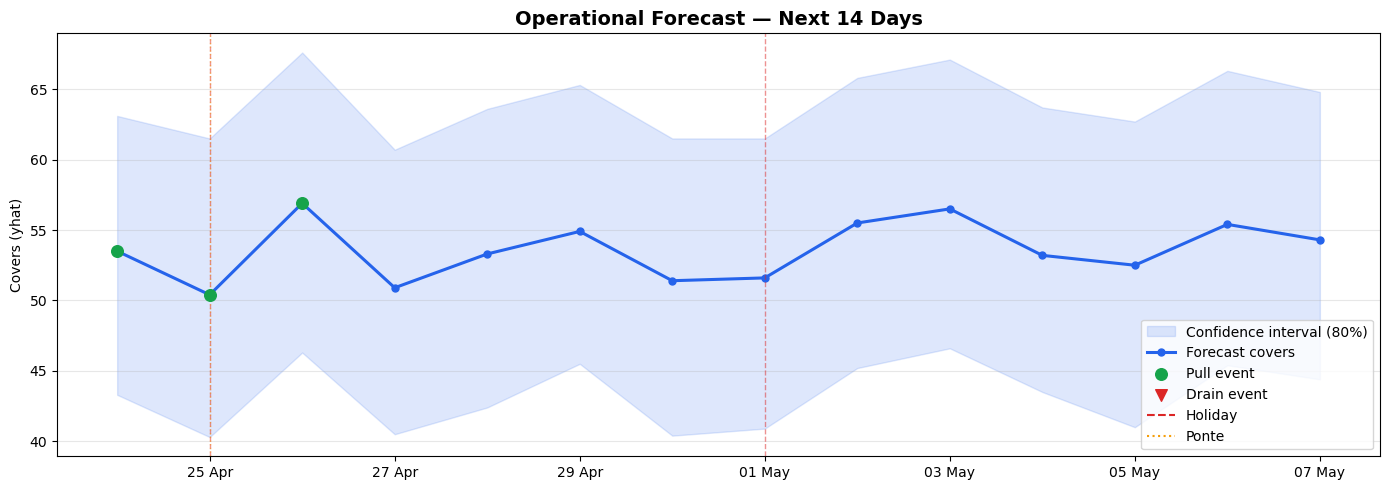

In [57]:
# ── 5. PREDICT & DISPLAY ─────────────────────────────────────────────────────
forecast_future = model.predict(future_df)

output = future_df[['ds']].copy()
output['yhat']       = forecast_future['yhat'].round(1)
output['yhat_lower'] = forecast_future['yhat_lower'].round(1)
output['yhat_upper'] = forecast_future['yhat_upper'].round(1)
output['weekday']    = output['ds'].dt.strftime('%a')
output['event_mag']  = future_df['event_magnitude'].values
output['event_pull'] = future_df['event_pull'].values
output['is_holiday'] = future_df['is_holiday'].values
output['is_ponte']   = future_df['is_ponte'].values

output = output[['ds', 'weekday', 'yhat', 'yhat_lower', 'yhat_upper',
                  'is_holiday', 'is_ponte', 'event_mag', 'event_pull']]

print("=" * 75)
print("OPERATIONAL FORECAST — 14 days (2026-04-24 → 2026-05-07)")
print("=" * 75)
display(output)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(output['ds'], output['yhat_lower'], output['yhat_upper'],
                alpha=0.15, color='#2563eb', label='Confidence interval (80%)')
ax.plot(output['ds'], output['yhat'], color='#2563eb', linewidth=2.2,
        marker='o', markersize=5, label='Forecast covers')

for _, row in output[output['is_holiday'] == 1].iterrows():
    ax.axvline(row['ds'], color='#dc2626', linestyle='--', alpha=0.5, linewidth=1.0)
for _, row in output[output['is_ponte'] == 1].iterrows():
    ax.axvline(row['ds'], color='#f59e0b', linestyle=':', alpha=0.5, linewidth=1.0)

# Pull events (green) and drain events (red scatter)
pull_days  = output[output['event_pull'] == 1]
drain_days = output[output['event_pull'] == -1]
ax.scatter(pull_days['ds'],  pull_days['yhat'],  color='#16a34a', zorder=5, s=70, label='Pull event')
ax.scatter(drain_days['ds'], drain_days['yhat'], color='#dc2626', zorder=5, s=70, marker='v', label='Drain event')

from matplotlib.lines import Line2D
legend_extra = [
    Line2D([0], [0], color='#dc2626', linestyle='--', label='Holiday'),
    Line2D([0], [0], color='#f59e0b', linestyle=':',  label='Ponte'),
]
ax.legend(handles=ax.get_legend_handles_labels()[0] + legend_extra)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set_title('Operational Forecast — Next 14 Days', fontsize=14, fontweight='bold')
ax.set_ylabel('Covers (yhat)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
